

In statistical genetics and genome-wide association studies (GWAS), two concepts appear repeatedly:

1. Genetic Relationship Matrix (GRM)
2. Population Stratification

These concepts are fundamental in modern genomics because genetic datasets often contain:

- related individuals,
- ancestry structure,
- subtle population differences,
- and hidden correlations between samples.

Without accounting for these effects, genetic analyses can become biased and produce false associations.

This tutorial explains:

- what a GRM is,
- how it is computed,
- why population stratification matters,
- and how these concepts are connected in modern GWAS pipelines.

## What is a Genetic Relationship Matrix (GRM)?

A **Genetic Relationship Matrix (GRM)** is a matrix that measures the genetic similarity between every pair of individuals in a dataset using genome-wide SNP data.

The GRM is also called:

- genomic relationship matrix,
- kinship matrix,
- realized relationship matrix,
- genomic covariance matrix.

It is widely used in:

- GWAS mixed models,
- SNP heritability estimation,
- GCTA,
- BOLT-LMM,
- REGENIE,
- genomic prediction,
- animal breeding,
- polygenic risk score methods.

### Intuition Behind the GRM

Suppose we genotype thousands of individuals across hundreds of thousands of SNPs.

Some individuals will naturally share more alleles than others because:

- they are relatives,
- they belong to similar ancestry groups,
- or they inherited similar genomic segments.

The GRM quantifies this similarity numerically.

If two individuals are genetically very similar, their GRM value will be high.

If they are unrelated, the value will be close to zero.




### Structure of a GRM

For $n$ individuals, the GRM is an $ n \times n $ matrix.

Example:

$
G =
\begin{bmatrix}
1.00 & 0.12 & -0.01 \\
0.12 & 1.00 & 0.03 \\
-0.01 & 0.03 & 1.00
\end{bmatrix}
$

Interpretation:

- diagonal values represent self-relatedness,
- off-diagonal values represent pairwise genetic similarity.

### Mathematical Definition

Suppose:

- $ X_{ij}$ is the genotype of individual $ i $ at SNP $j$,
- encoded as 0, 1, or 2 copies of the reference allele.

The GRM is usually computed as:

$
G = \frac{1}{M} \sum_{j=1}^{M}
\frac{(x_{ij} - 2p_j)(x_{kj} - 2p_j)}
{2p_j(1-p_j)}
$

where:

- $ M $ = number of SNPs,
- $ p_j $ = allele frequency at SNP $ j $.

This formula:

1. centers genotypes,
2. normalizes by variance,
3. averages similarity across SNPs.

### Why Standardization Matters

Without normalization:

- common variants dominate,
- allele frequency differences distort similarity estimates.

Standardization ensures that each SNP contributes appropriately.

### Interpretation of GRM Values

| GRM Value | Interpretation |
|---|---|
| ~1 | identical individuals / twins |
| ~0.5 | siblings or parent-child |
| ~0.25 | second-degree relatives |
| ~0 | unrelated |
| negative small values | less similar than average |

In large GWAS datasets, most unrelated individuals have GRM values close to zero.

### Why is the GRM Important?

### Modeling Relatedness

Genetic datasets rarely contain perfectly independent individuals.

The GRM allows mixed models to account for relatedness.

### SNP Heritability Estimation

Methods like GCTA-GREML use the GRM to estimate SNP heritability.

The mixed model is:

$
y = X\beta + g + \epsilon
$

where:

$
g \sim N(0, G\sigma_g^2)
$

The GRM defines the covariance structure of genetic effects.

### Correcting GWAS Inflation

Related individuals can inflate association statistics.

Linear mixed models use the GRM to absorb polygenic background effects.

### GRM in Linear Mixed Models

A standard mixed model is:

$
y = X\beta + Zu + \epsilon
$
with:

$
u \sim N(0, G\sigma_g^2)
$

The GRM tells the model:

> individuals with similar genomes may also have correlated phenotypes.

### Population Stratification

Population stratification refers to:

> systematic ancestry differences within a dataset.

Different ancestry groups often differ in:

- allele frequencies,
- environmental exposures,
- lifestyle,
- disease prevalence.

This creates confounding in GWAS.

### Simple Example of Population Stratification

Suppose a dataset contains:

- Northern Europeans,
- Southern Europeans.

Assume:

- a SNP is more common in Northern Europeans,
- Northern Europeans are also taller on average.

A GWAS may incorrectly conclude:

> the SNP causes height

even if the SNP has no biological effect.

The association arises because ancestry influences both genotype and phenotype.

### Why Population Stratification Happens

Human populations are not genetically homogeneous.

Historical processes such as:

- migration,
- founder effects,
- isolation,
- drift,
- natural selection

create differences in allele frequencies across populations.

### Population Stratification Produces False Positives

GWAS assumes:


```text
Genotype independent of confounders
```

Population structure violates this assumption because:
```text
Ancestry affects both genotype and phenotype
```

leading to spurious associations.

### Detecting Population Stratification Using PCA

Principal Component Analysis (PCA) is commonly used to visualize ancestry structure.

Individuals with similar ancestry cluster together in PCA space.

### Relationship Between GRM and PCA

PCA is mathematically related to eigendecomposition of the GRM.

If:

$
G = U \Lambda U^T
$

then columns of \( U \) represent principal genetic axes.

These axes often correspond to ancestry differences.

### Correcting Population Stratification

Several methods are commonly used.


### Principal Components

GWAS models usually include ancestry PCs as covariates:

$
y = X\beta + PC_1 + PC_2 + \cdots + \epsilon
$


These PCs summarize ancestry variation.

## Linear Mixed Models

Mixed models using the GRM also partially correct stratification.

## Restricting Ancestry

Many studies analyze a single ancestry group only.

Examples:

- Finnish-only datasets,
- East Asian-only cohorts,
- European ancestry subsets.

### Connection Between GRM and Population Stratification

The GRM captures:

- family relatedness,
- ancestry similarity,
- subtle population structure.

Therefore, population structure is directly reflected inside the GRM.

This is why:

- eigenvectors of the GRM resemble ancestry PCs.

### GRM vs Population Stratification

| Concept | GRM | Population Stratification |
|---|---|---|
| What is it? | Matrix of genetic similarity | Ancestry structure |
| Mathematical object? | Yes | Biological/statistical phenomenon |
| Purpose | Model covariance | Source of confounding |
| Used directly in models? | Yes | Corrected indirectly |
| Connected to PCA? | Yes | Revealed through PCA |


### Practical Example in Modern GWAS

Large datasets such as:

- :contentReference[oaicite:0]{index=0}
- :contentReference[oaicite:1]{index=1}

routinely:

1. compute PCs,
2. remove ancestry outliers,
3. use GRM-based mixed models,
4. correct for relatedness,
5. evaluate genomic inflation.






### Simple Python Example: Simulating a GRM

In [1]:

import numpy as np
import pandas as pd

np.random.seed(42)

# Simulate genotype matrix
# rows = individuals
# columns = SNPs

n_individuals = 5
n_snps = 100

genotypes = np.random.randint(0, 3, size=(n_individuals, n_snps))

# Allele frequencies
p = genotypes.mean(axis=0) / 2

# Standardize genotypes
Z = (genotypes - 2 * p) / np.sqrt(2 * p * (1 - p) + 1e-8)

# Compute GRM
GRM = (Z @ Z.T) / n_snps

grm_df = pd.DataFrame(
    GRM,
    columns=[f"ID{i+1}" for i in range(n_individuals)],
    index=[f"ID{i+1}" for i in range(n_individuals)]
)

grm_df.round(3)

,ID1,ID2,ID3,ID4,ID5
ID1,1.181,-0.343,-0.344,-0.345,-0.149
ID2,-0.343,1.322,-0.293,-0.359,-0.326
ID3,-0.344,-0.293,1.324,-0.266,-0.420
ID4,-0.345,-0.359,-0.266,1.196,-0.226
ID5,-0.149,-0.326,-0.420,-0.226,1.121


### Visualizing the GRM

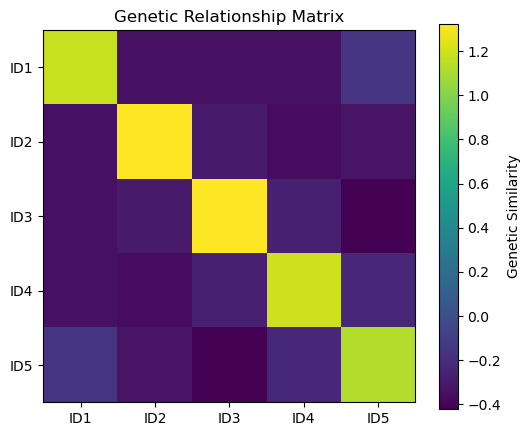

In [2]:

import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.imshow(GRM)
plt.colorbar(label="Genetic Similarity")
plt.title("Genetic Relationship Matrix")
plt.xticks(range(n_individuals), grm_df.columns)
plt.yticks(range(n_individuals), grm_df.index)
plt.show()


### Summary

The Genetic Relationship Matrix (GRM) measures genome-wide genetic similarity between individuals and forms the foundation of many modern statistical genetics methods.

Population stratification refers to ancestry differences within datasets that can create false associations in GWAS.

These concepts are deeply connected because ancestry influences genome-wide genetic similarity.

Modern GWAS pipelines routinely combine:

- PCA correction,
- GRM-based mixed models,
- ancestry filtering,
- genomic inflation diagnostics

to produce robust and reliable association results.

### References

1. Yang J et al. (2011). GCTA: A Tool for Genome-wide Complex Trait Analysis.
2. Price AL et al. (2006). Principal Components Analysis Corrects for Stratification in GWAS.
3. Patterson N et al. (2006). Population Structure and Eigenanalysis.
4. Lee SH et al. (2012). Estimation of SNP Heritability.
5. Purcell S et al. PLINK documentation.

